In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('OpenAlexData.csv', index_col=0)

C:\Users\wieke\AppData\Local\Temp\ipykernel_4972\2055085896.py:1: DtypeWarning: Columns (8,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('OpenAlexData.csv', index_col=0)


In [3]:
pd.set_option("display.max_columns", 55)


In [4]:
def counts(col1, col2, col3, df):
    oa_count_s = df.groupby([col1])[col2].value_counts().unstack(col2).reset_index()
    oa_count_s = oa_count_s.fillna(0)
    
    oa_count_s[col3] = oa_count_s[True] / (oa_count_s[False] + oa_count_s[True])
    oa_count_s
    return oa_count_s.sort_values(by=[col3], ascending=False)
    



In [5]:
def multiple_counts(col1, col2, col3, col4, df):
    oa_count_s = df.groupby([col1, col2])[col3].value_counts().unstack(col3).reset_index()
    oa_count_s = oa_count_s.fillna(0)
    
    oa_count_s[col4] = oa_count_s[True] / (oa_count_s[False] + oa_count_s[True])
    
    return oa_count_s


In [6]:
def oa_status(df, col1, col2, sorted):
    oa_status_df = df.groupby([col1])[col2].value_counts().unstack(col2).reset_index()
    oa_status_df = oa_status_df.fillna(0)
    oa_status_df['total'] = oa_status_df['bronze'] + oa_status_df['closed'] + oa_status_df['gold'] + oa_status_df['green'] + oa_status_df['hybrid']
    oa_status_df['hybrid %'] = oa_status_df['hybrid'] / oa_status_df['total']
    oa_status_df['green %'] = oa_status_df['green'] / oa_status_df['total']
    oa_status_df['gold %'] = oa_status_df['gold'] / oa_status_df['total']
    oa_status_df['closed %'] = oa_status_df['closed'] / oa_status_df['total']
    oa_status_df['bronze %'] = oa_status_df['bronze'] / oa_status_df['total']
    dct = {'hybrid %': 'hybrid', 'green %': 'green', 'gold %': 'gold', 'closed %': 'closed', 'bronze %': 'bronze'}
    oa_status_df['Most used OA type'] = oa_status_df[['hybrid %', 'green %', 'gold %', 'closed %', 'bronze %']].idxmax(axis=1).map(dct)

    #oa_status_df = oa_status_df.sort_values(by=[sort], ascending=False)
    oa_status_df = oa_status_df.sort_values(by=[sorted], ascending=False).reset_index(drop=True)

    return oa_status_df

In [7]:
df2012 = df[df['publication_year'] == 2012]


In [8]:
field_name_df2012 = counts('field_name', 'is_oa', 'OA %', df2012)
field_name_df2012 = field_name_df2012.head(50).sort_index(ascending=True) #.reset_index(drop=True) #.sort_values(by='OA %')
field_name_df2012

is_oa,field_name,False,True,OA %
0,Agricultural and Biological Sciences,47.0,18.0,0.276923
1,Arts and Humanities,1.0,1.0,0.500000
2,"Biochemistry, Genetics and Molecular Biology",235.0,129.0,0.354396
3,"Business, Management and Accounting",1.0,16.0,0.941176
4,Chemical Engineering,1.0,2.0,0.666667
5,Chemistry,15.0,14.0,0.482759
6,Computer Science,10.0,47.0,0.824561
7,Decision Sciences,3.0,35.0,0.921053
8,Dentistry,2.0,0.0,0.000000
9,Earth and Planetary Sciences,4.0,10.0,0.714286


<Axes: ylabel='field_name'>

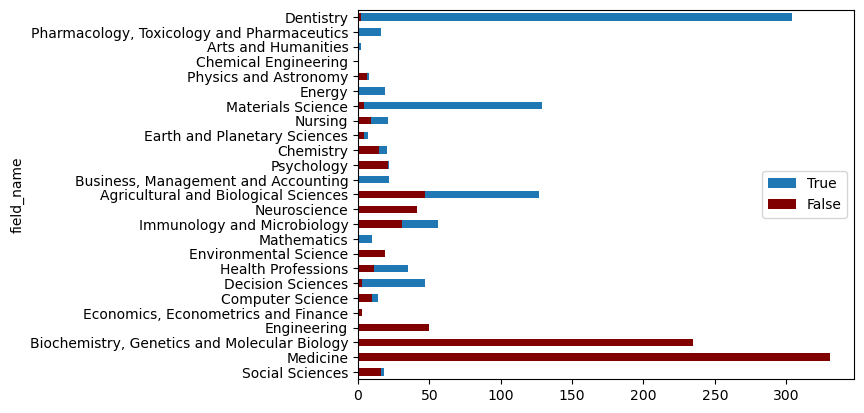

In [9]:
ax = field_name_df2012.plot(x="field_name", y=True, kind="barh") 
field_name_df2012.sort_values(True, ascending=False).plot(x="field_name", y=False, kind="barh", ax=ax, color="maroon")  



In [10]:
df2024 = df[df['publication_year'] == 2024]

In [11]:
field_name_df2024 = counts('field_name', 'is_oa', 'OA %', df2024)
field_name_df2024 = field_name_df2024.head(50).sort_index(ascending=True) #.reset_index(drop=True) #.sort_values(by='OA %')
field_name_df2024

is_oa,field_name,False,True,OA %
0,Agricultural and Biological Sciences,15.0,4.0,0.210526
1,Arts and Humanities,2.0,0.0,0.000000
2,"Biochemistry, Genetics and Molecular Biology",29.0,52.0,0.641975
3,"Business, Management and Accounting",0.0,4.0,1.000000
4,Chemistry,2.0,0.0,0.000000
5,Computer Science,33.0,21.0,0.388889
6,Earth and Planetary Sciences,10.0,9.0,0.473684
7,"Economics, Econometrics and Finance",0.0,12.0,1.000000
8,Energy,0.0,1.0,1.000000
9,Engineering,15.0,8.0,0.347826


<Axes: ylabel='field_name'>

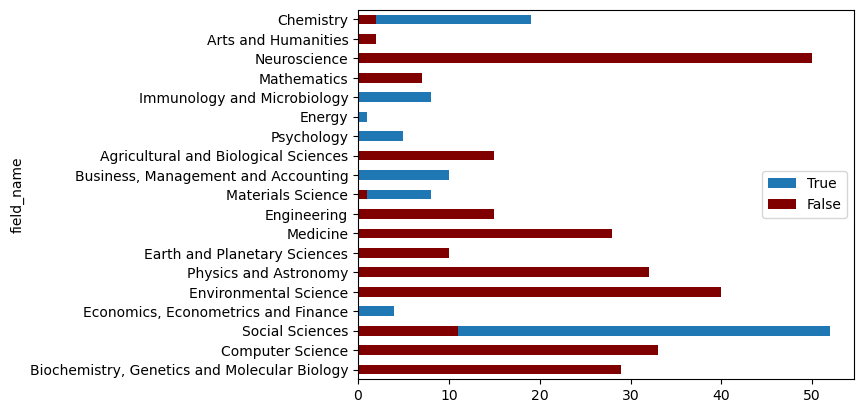

In [12]:
ax = field_name_df2024.plot(x="field_name", y=True, kind="barh") 
field_name_df2024.sort_values(True, ascending=False).plot(x="field_name", y=False, kind="barh", ax=ax, color="maroon") 

In [44]:
subtract_year_df = field_name_df2024['OA %'] - field_name_df2012['OA %']
subtract_year_df = pd.concat([subtract_year_df, field_name_df2024['field_name']], axis=1)
subtract_year_df.sort_values('OA %', ascending=False)

,OA %,field_name
8,1.000000,Energy
18,0.352899,Social Sciences
2,0.287580,"Biochemistry, Genetics and Molecular Biology"
12,0.115819,Materials Science
7,0.078947,"Economics, Econometrics and Finance"
3,0.058824,"Business, Management and Accounting"
17,0.000000,Psychology
11,0.000000,Immunology and Microbiology
0,-0.066397,Agricultural and Biological Sciences
5,-0.093870,Computer Science


<Axes: ylabel='field_name'>

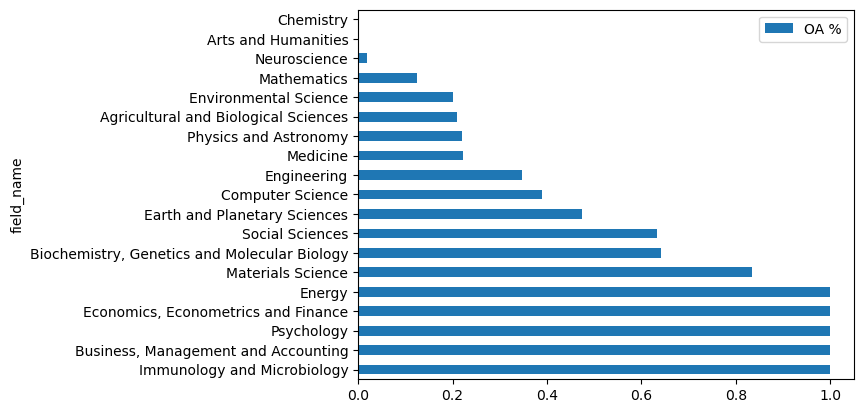

In [14]:
ax = field_name_df2024.sort_values('OA %', ascending=False).plot(x="field_name", y='OA %', kind="barh") 
ax


In [15]:
field_name_df2012 = counts('field_name', 'is_oa', 'OA %', df2012)
field_name_df2012 = field_name_df2012.head(50).sort_index(ascending=True) #.reset_index(drop=True) #.sort_values(by='OA %')
field_name_df2012

is_oa,field_name,False,True,OA %
0,Agricultural and Biological Sciences,47.0,18.0,0.276923
1,Arts and Humanities,1.0,1.0,0.500000
2,"Biochemistry, Genetics and Molecular Biology",235.0,129.0,0.354396
3,"Business, Management and Accounting",1.0,16.0,0.941176
4,Chemical Engineering,1.0,2.0,0.666667
5,Chemistry,15.0,14.0,0.482759
6,Computer Science,10.0,47.0,0.824561
7,Decision Sciences,3.0,35.0,0.921053
8,Dentistry,2.0,0.0,0.000000
9,Earth and Planetary Sciences,4.0,10.0,0.714286


In [16]:
institution_df2012= df2012.groupby(['institution_name'])['is_oa'].value_counts().unstack('is_oa').reset_index()
institution_df2012['OA %'] = institution_df2012[True] / (institution_df2012[False] + institution_df2012[True])
#oa_count_s
institution_df2012.sort_values(by=['OA %'], ascending=False)

is_oa,institution_name,False,True,OA %
4,Princeton University,32.0,157.0,0.830688
15,Washington University in St. Louis,25.0,101.0,0.801587
7,University of Michigan–Ann Arbor,165.0,638.0,0.794521
12,University of Virginia,44.0,109.0,0.712418
1,Duke University,76.0,162.0,0.680672
3,Pennsylvania State University,71.0,122.0,0.632124
0,Cornell University,94.0,86.0,0.477778
2,New York University,46.0,41.0,0.471264
5,University of Colorado Boulder,18.0,15.0,0.454545
14,Virginia Tech,9.0,7.0,0.437500


<Axes: ylabel='institution_name'>

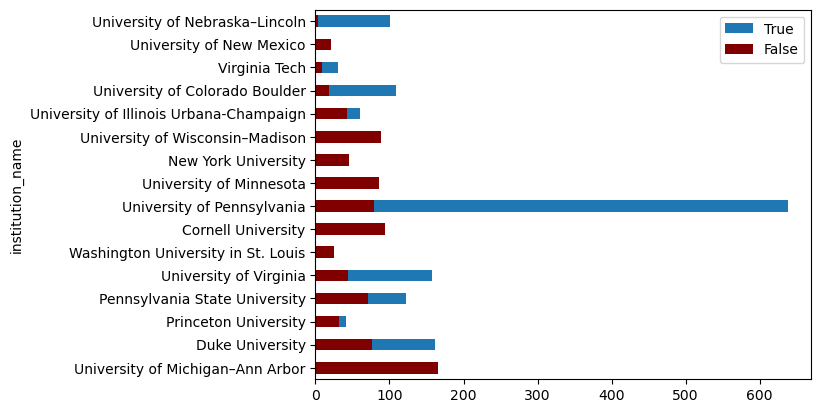

In [17]:
institution_df2012_ax = institution_df2012.plot(x="institution_name", y=True, kind="barh") 
institution_df2012.sort_values(True, ascending=False).plot(x="institution_name", y=False, kind="barh", ax=institution_df2012_ax, color="maroon") 

In [18]:
institution_df2024= df2024.groupby(['institution_name'])['is_oa'].value_counts().unstack('is_oa').reset_index()
institution_df2024['OA %'] = institution_df2024[True] / (institution_df2024[False] + institution_df2024[True])
#oa_count_s
institution_df2024.sort_values(by=['OA %'], ascending=False)

is_oa,institution_name,False,True,OA %
10,University of Pennsylvania,3,9,0.750000
2,New York University,3,7,0.700000
1,Duke University,6,12,0.666667
7,University of Michigan–Ann Arbor,14,25,0.641026
13,Virginia Tech,6,10,0.625000
12,University of Wisconsin–Madison,22,26,0.541667
14,Washington University in St. Louis,13,14,0.518519
11,University of Virginia,4,4,0.500000
0,Cornell University,56,29,0.341176
5,University of Colorado Boulder,2,1,0.333333


<Axes: ylabel='institution_name'>

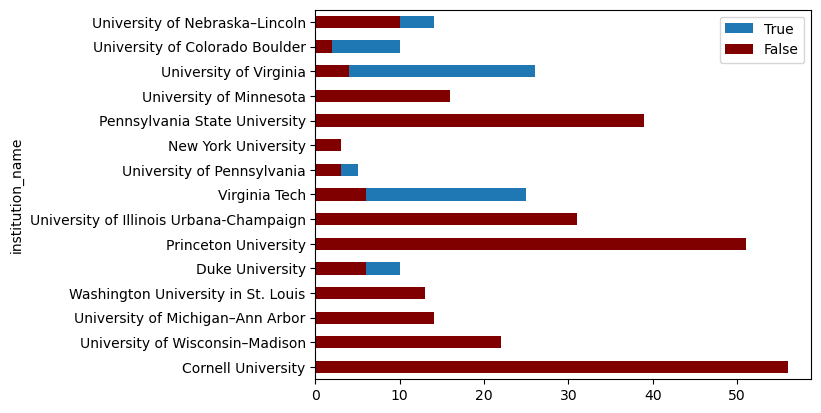

In [19]:
institution_df2024_ax = institution_df2024.plot(x="institution_name", y=True, kind="barh") 
institution_df2024.sort_values(True, ascending=False).plot(x="institution_name", y=False, kind="barh", ax=institution_df2024_ax, color="maroon") 

In [20]:
subtract_inst_year_df = institution_df2024['OA %'] - institution_df2012['OA %']
subtract_inst_year_df = pd.concat([subtract_inst_year_df, institution_df2024['institution_name']], axis=1)
subtract_inst_year_df

,OA %,institution_name
0,-0.136601,Cornell University
1,-0.014006,Duke University
2,0.228736,New York University
3,-0.498791,Pennsylvania State University
4,-0.666753,Princeton University
5,-0.121212,University of Colorado Boulder
6,-0.094559,University of Illinois Urbana-Champaign
7,-0.153495,University of Michigan–Ann Arbor
8,-0.095238,University of Minnesota
9,NaN,University of Nebraska–Lincoln


<Axes: ylabel='institution_name'>

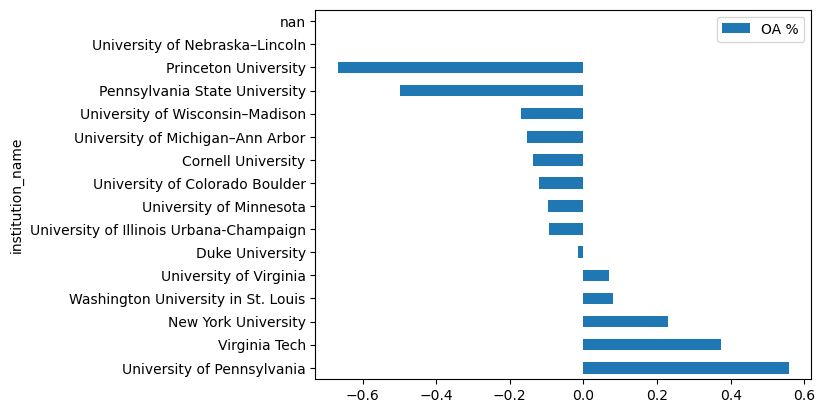

In [21]:
ax = subtract_inst_year_df.sort_values('OA %', ascending=False).plot(x="institution_name", y='OA %', kind="barh") 
ax

In [22]:
pubyear_df = df.groupby(['institution_name'])['publication_year'].count().sort_values(ascending=False)
pubyear_df


institution_name
University of Michigan–Ann Arbor           448762
Cornell University                          11869
Washington University in St. Louis           7996
Duke University                              7853
University of Wisconsin–Madison              7331
Princeton University                         6430
New York University                          5437
Pennsylvania State University                4200
University of Pennsylvania                   3375
University of Illinois Urbana-Champaign      3300
University of Virginia                       3119
University of Nebraska–Lincoln               2624
University of Minnesota                      2551
University of Colorado Boulder               1430
Virginia Tech                                1077
University of New Mexico                      420
Michael J. Fox Foundation                       6
Name: publication_year, dtype: int64

In [23]:
pubyear_df = df.copy()
pubyear_df = df[df['publication_year'] >= 2012]

pubyear_df = pubyear_df.groupby(['institution_name', 'is_oa'])['publication_year'].value_counts().unstack().reset_index()
pubyear_df = pubyear_df.fillna(0)
#pubyear_df['sum'] = pubyear_df.sum(axis=1)
#pubyear_df['OA %'] = pubyear_df['is_oa'] / (pubyear_df['is_oa'] + pubyear_df['is_oa'])
pubyear_df['Total'] = pubyear_df[2012] + pubyear_df[2013] + pubyear_df[2014] + pubyear_df[2015] + pubyear_df[2016] + pubyear_df[2017] +pubyear_df[2018] + pubyear_df[2019] + pubyear_df[2020] + pubyear_df[2021] + pubyear_df[2022] +  pubyear_df[2023] + pubyear_df[2024] + pubyear_df[2025]
#pubyear['OA%'] = pubyear_df['Total'] / (pubyear_df['is_oa'] + pubyear_df['is_oa'])
#pubyear_df['False Total'] = pubyear_df.loc[pubyear_df['is_oa'] == False].sum()
  #  return oa_count_s.sort_values(by=[col3], ascending=False)
pubyear_df

publication_year,institution_name,is_oa,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Total
0,Cornell University,False,94.0,85.0,61.0,17.0,65.0,45.0,68.0,77.0,90.0,187.0,1974.0,80.0,56.0,0.0,2899.0
1,Cornell University,True,86.0,116.0,21.0,23.0,183.0,87.0,2181.0,3046.0,874.0,278.0,682.0,424.0,29.0,0.0,8030.0
2,Duke University,False,76.0,95.0,36.0,84.0,104.0,26.0,31.0,152.0,453.0,491.0,1059.0,92.0,6.0,1.0,2706.0
3,Duke University,True,162.0,68.0,27.0,114.0,439.0,304.0,196.0,514.0,1345.0,244.0,377.0,276.0,12.0,0.0,4078.0
4,Michael J. Fox Foundation,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
5,Michael J. Fox Foundation,True,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,5.0
6,New York University,False,46.0,56.0,71.0,14.0,18.0,39.0,26.0,34.0,123.0,66.0,37.0,61.0,3.0,0.0,594.0
7,New York University,True,41.0,44.0,32.0,35.0,44.0,116.0,287.0,871.0,1556.0,190.0,389.0,330.0,7.0,0.0,3942.0
8,Pennsylvania State University,False,71.0,65.0,27.0,7.0,20.0,26.0,22.0,24.0,33.0,205.0,41.0,123.0,39.0,0.0,703.0
9,Pennsylvania State University,True,122.0,47.0,20.0,25.0,49.0,51.0,161.0,636.0,683.0,256.0,401.0,389.0,6.0,0.0,2846.0


In [24]:
oa_count_s = df.groupby(['institution_name'])['is_oa'].value_counts().unstack('is_oa').reset_index()
oa_count_s['OA %'] = oa_count_s[True] / (oa_count_s[False] + oa_count_s[True])
#oa_count_s
oa_count_s.sort_values(by=['OA %'], ascending=False)

is_oa,institution_name,False,True,OA %
8,University of Michigan–Ann Arbor,2840,445922,0.993671
5,Princeton University,712,5718,0.889269
15,Virginia Tech,170,907,0.842154
2,Michael J. Fox Foundation,1,5,0.833333
3,New York University,1092,4345,0.799154
4,Pennsylvania State University,934,3266,0.777619
0,Cornell University,3549,8320,0.700986
13,University of Virginia,1020,2099,0.672972
6,University of Colorado Boulder,476,954,0.667133
12,University of Pennsylvania,1159,2216,0.656593


In [25]:
new_oa_count_s = oa_count_s[['institution_name', 'OA %']]
new_oa_count_s
#new_oa_count_s = new_oa_count_s.set_index('institution_name', drop=True,inplace=True)
#new_oa_count_s.index.values

is_oa,institution_name,OA %
0,Cornell University,0.700986
1,Duke University,0.568318
2,Michael J. Fox Foundation,0.833333
3,New York University,0.799154
4,Pennsylvania State University,0.777619
5,Princeton University,0.889269
6,University of Colorado Boulder,0.667133
7,University of Illinois Urbana-Champaign,0.595758
8,University of Michigan–Ann Arbor,0.993671
9,University of Minnesota,0.437083


In [26]:
inst_domain_df = df.groupby(['institution_name', 'domain_name']).size().sort_values(ascending=False)
inst_domain_df.head(50)

institution_name                         domain_name      
University of Michigan–Ann Arbor         Physical Sciences    18441
                                         Life Sciences         9479
Cornell University                       Physical Sciences     7518
University of Michigan–Ann Arbor         Health Sciences       6088
Washington University in St. Louis       Physical Sciences     5350
University of Michigan–Ann Arbor         Social Sciences       5283
University of Wisconsin–Madison          Physical Sciences     4094
Duke University                          Physical Sciences     3133
Princeton University                     Physical Sciences     2275
University of Nebraska–Lincoln           Physical Sciences     1919
Cornell University                       Life Sciences         1649
Pennsylvania State University            Physical Sciences     1627
New York University                      Social Sciences       1348
                                         Physical Science

In [27]:
oa_count_df = df.groupby(['institution_name', 'is_oa']).size().sort_values(ascending=False)
oa_count_df.head(25)


institution_name                         is_oa
University of Michigan–Ann Arbor         True     445922
Cornell University                       True       8320
Princeton University                     True       5718
Washington University in St. Louis       False      5263
Duke University                          True       4463
New York University                      True       4345
University of Wisconsin–Madison          True       3773
                                         False      3558
Cornell University                       False      3549
Duke University                          False      3390
Pennsylvania State University            True       3266
University of Michigan–Ann Arbor         False      2840
Washington University in St. Louis       True       2733
University of Pennsylvania               True       2216
University of Virginia                   True       2099
University of Illinois Urbana-Champaign  True       1966
University of Nebraska–Lincoln           

In [28]:
oa_count_df = df.groupby(['institution_name'])['is_oa'].value_counts().unstack('is_oa').reset_index()
oa_count_df


is_oa,institution_name,False,True
0,Cornell University,3549,8320
1,Duke University,3390,4463
2,Michael J. Fox Foundation,1,5
3,New York University,1092,4345
4,Pennsylvania State University,934,3266
5,Princeton University,712,5718
6,University of Colorado Boulder,476,954
7,University of Illinois Urbana-Champaign,1334,1966
8,University of Michigan–Ann Arbor,2840,445922
9,University of Minnesota,1436,1115


In [29]:
field_oa_df = counts('field_name', 'is_oa', 'OA %', df)
field_oa_df 

is_oa,field_name,False,True,OA %
10,"Economics, Econometrics and Finance",32,2285,0.986189
3,"Business, Management and Accounting",45,1479,0.970472
7,Decision Sciences,75,2152,0.966322
17,Mathematics,22,461,0.954451
24,Social Sciences,325,6768,0.954180
5,Chemistry,339,6298,0.948923
22,Physics and Astronomy,451,7518,0.943406
16,Materials Science,176,2586,0.936278
6,Computer Science,523,5890,0.918447
12,Engineering,715,6460,0.900348


In [30]:
domain_oa_df = counts('domain_name', 'is_oa', 'OA %', df)
domain_oa_df

is_oa,domain_name,False,True,OA %
3,Social Sciences,907,13423,0.936706
1,Life Sciences,6551,14643,0.690903
2,Physical Sciences,15749,33873,0.682621
0,Health Sciences,4829,8840,0.646719


In [31]:
subfield_name_df = counts('subfield_name', 'is_oa', 'OA %', df)
subfield_name_df.head(25)


is_oa,subfield_name,False,True,OA %
120,Industrial relations,0.0,8.0,1.000000
94,General Energy,0.0,35.0,1.000000
63,Discrete Mathematics and Combinatorics,0.0,10.0,1.000000
140,Mathematical Physics,0.0,8.0,1.000000
49,Computer Graphics and Computer-Aided Design,0.0,59.0,1.000000
145,Medical Terminology,0.0,1.0,1.000000
88,Fuel Technology,0.0,11.0,1.000000
151,Museology,0.0,6.0,1.000000
40,Classics,0.0,3.0,1.000000
158,Numerical Analysis,0.0,6.0,1.000000


In [32]:
topic_name_df = counts('topic_name', 'is_oa', 'OA %', df)
topic_name_df.head(25)

is_oa,topic_name,False,True,OA %
1426,"Innovation, Technology, and Society",0.0,8.0,1.0
2076,Pharmacovigilance and Adverse Drug Reactions,0.0,1.0,1.0
932,Environmental Impact and Sustainability,0.0,34.0,1.0
2056,Personal Information Management and User Behavior,0.0,2.0,1.0
928,Environmental Conservation and Management,0.0,4.0,1.0
927,Environmental Chemistry and Analysis,0.0,1.0,1.0
2058,Personality Traits and Psychology,0.0,8.0,1.0
2062,Petroleum Processing and Analysis,0.0,4.0,1.0
2072,Pharmacological Effects of Medicinal Plants,0.0,1.0,1.0
921,Enhanced Oil Recovery Techniques,0.0,6.0,1.0


In [33]:
funding_oa_status_df = oa_status(df, 'funding_type', 'oa_status', 'green %')
funding_oa_status_df

oa_status,funding_type,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,funder,4714.0,29062.0,48307.0,406.0,435281.0,517770.0,0.840684,0.000784,0.093298,0.056129,0.009104,hybrid
1,education,0.0,0.0,2.0,0.0,2.0,4.0,0.500000,0.000000,0.500000,0.000000,0.000000,hybrid
2,nonprofit,0.0,1.0,5.0,0.0,0.0,6.0,0.000000,0.000000,0.833333,0.166667,0.000000,gold


In [34]:
inst_oa_status_df = oa_status(df, 'institution_name', 'oa_status', 'green %')
inst_oa_status_df

oa_status,institution_name,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,Virginia Tech,82.0,170.0,752.0,26.0,47.0,1077.0,0.043640,0.024141,0.698236,0.157846,0.076137,gold
1,University of Pennsylvania,347.0,1159.0,1793.0,67.0,9.0,3375.0,0.002667,0.019852,0.531259,0.343407,0.102815,gold
2,University of New Mexico,66.0,273.0,64.0,8.0,9.0,420.0,0.021429,0.019048,0.152381,0.650000,0.157143,closed
3,University of Illinois Urbana-Champaign,348.0,1334.0,1570.0,29.0,19.0,3300.0,0.005758,0.008788,0.475758,0.404242,0.105455,gold
4,University of Colorado Boulder,109.0,476.0,825.0,11.0,9.0,1430.0,0.006294,0.007692,0.576923,0.332867,0.076224,gold
5,University of Nebraska–Lincoln,47.0,1856.0,701.0,17.0,3.0,2624.0,0.001143,0.006479,0.267149,0.707317,0.017912,closed
6,Duke University,472.0,3390.0,3382.0,42.0,567.0,7853.0,0.072202,0.005348,0.430663,0.431682,0.060104,closed
7,University of Virginia,336.0,1020.0,1748.0,14.0,1.0,3119.0,0.000321,0.004489,0.560436,0.327028,0.107727,gold
8,University of Wisconsin–Madison,351.0,3558.0,3354.0,32.0,36.0,7331.0,0.004911,0.004365,0.457509,0.485336,0.047879,closed
9,Princeton University,160.0,712.0,5511.0,24.0,23.0,6430.0,0.003577,0.003733,0.857076,0.110731,0.024883,gold


In [35]:
field_oa_status_df = oa_status(df,  'field_name', 'oa_status', 'green %')
field_oa_status_df

oa_status,field_name,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,Psychology,112.0,361.0,284.0,80.0,2.0,839.0,0.002384,0.095352,0.338498,0.430274,0.133492,closed
1,Arts and Humanities,10.0,69.0,187.0,12.0,52.0,330.0,0.157576,0.036364,0.566667,0.209091,0.030303,gold
2,Nursing,28.0,81.0,35.0,4.0,0.0,148.0,0.000000,0.027027,0.236486,0.547297,0.189189,closed
3,Health Professions,59.0,207.0,246.0,11.0,147.0,670.0,0.219403,0.016418,0.367164,0.308955,0.088060,gold
4,Immunology and Microbiology,218.0,562.0,273.0,16.0,220.0,1289.0,0.170675,0.012413,0.211792,0.435997,0.169123,closed
5,Social Sciences,65.0,325.0,5299.0,84.0,1320.0,7093.0,0.186099,0.011843,0.747075,0.045820,0.009164,gold
6,Decision Sciences,13.0,75.0,1062.0,22.0,1055.0,2227.0,0.473731,0.009879,0.476875,0.033678,0.005837,gold
7,Mathematics,9.0,22.0,447.0,3.0,2.0,483.0,0.004141,0.006211,0.925466,0.045549,0.018634,gold
8,Neuroscience,288.0,881.0,345.0,9.0,10.0,1533.0,0.006523,0.005871,0.225049,0.574690,0.187867,closed
9,Engineering,278.0,715.0,3219.0,30.0,2933.0,7175.0,0.408780,0.004181,0.448641,0.099652,0.038746,gold


In [36]:
license_oa_status_df = oa_status(df,  'license', 'oa_status', 'gold %')
license_oa_status_df

oa_status,license,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,cc-by-nd,0.0,0.0,4.0,0.0,0.0,4.0,0.000000,0.000000,1.000000,0.000000,0.00000,gold
1,other-oa,0.0,29.0,31883.0,9.0,3.0,31924.0,0.000094,0.000282,0.998716,0.000908,0.00000,gold
2,cc-by-sa,0.0,1.0,48.0,0.0,0.0,49.0,0.000000,0.000000,0.979592,0.020408,0.00000,gold
3,gpl-v3,0.0,3.0,60.0,0.0,0.0,63.0,0.000000,0.000000,0.952381,0.047619,0.00000,gold
4,mit,0.0,10.0,66.0,0.0,8.0,84.0,0.095238,0.000000,0.785714,0.119048,0.00000,gold
5,cc-by-nc-nd,0.0,12.0,24.0,0.0,1.0,37.0,0.027027,0.000000,0.648649,0.324324,0.00000,gold
6,cc-by-nc,0.0,1.0,92.0,0.0,76.0,169.0,0.449704,0.000000,0.544379,0.005917,0.00000,gold
7,apache-2-0,0.0,11.0,5.0,0.0,0.0,16.0,0.000000,0.000000,0.312500,0.687500,0.00000,closed
8,cc-by-nc-sa,0.0,18.0,11.0,0.0,8.0,37.0,0.216216,0.000000,0.297297,0.486486,0.00000,closed
9,cc-by,9.0,838.0,15920.0,19.0,435079.0,451865.0,0.962852,0.000042,0.035232,0.001855,0.00002,hybrid


In [37]:
index_oa_status_df = oa_status(df, 'index location', 'oa_status', 'green %')
index_oa_status_df

oa_status,index location,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,arxiv,0.0,0.0,0.0,13.0,0.0,13.0,0.000000,1.000000,0.000000,0.000000,0.00000,green
1,crossref,4705.0,14267.0,0.0,349.0,435280.0,454601.0,0.957499,0.000768,0.000000,0.031384,0.01035,hybrid
2,datacite,9.0,1555.0,48314.0,21.0,3.0,49902.0,0.000060,0.000421,0.968178,0.031161,0.00018,gold


In [38]:
MN_df = df[df['institution_name'] == 'University of Minnesota']
MN_df

,id,doi,type,funding_type,title,publication_year,publication_date,language,topic_id,topic_name,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name,retracted,index location,Repository,is_oa,oa_status,license,author_id,author_name,author_position,orcid,institution_id,institution_name,raw_affiliation_strings,country_code,ror,lineage
6,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5016996755,Claire Porter,first,https://orcid.org/0009-0005-4979-9778,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
7,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5074382278,Paul Morin,middle,https://orcid.org/0000-0002-4512-0642,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
9,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5114168374,Cole Kelleher,middle,NaN,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
10,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5111210501,Michael Cloutier,middle,NaN,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
11,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5098790376,Eric Husby,middle,NaN,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517323,https://openalex.org/W4398340829,https://doi.org/10.7910/dvn/awsqtw,dataset,funder,Replication Data for: Parties as Disciplinaria...,2021,2021-01-01,en,https://openalex.org/T10557,Social Media and Politics,https://openalex.org/subfields/3315,Communication,https://openalex.org/fields/33,Social Sciences,https://openalex.org/domains/2,Social Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,

In [39]:
MN_oa_df = counts('field_name', 'is_oa', 'OA %', MN_df)
MN_oa_df

is_oa,field_name,False,True,OA %
9,"Economics, Econometrics and Finance",3.0,36.0,0.923077
6,Decision Sciences,2.0,17.0,0.894737
23,Social Sciences,17.0,122.0,0.877698
21,Physics and Astronomy,11.0,78.0,0.876404
16,Mathematics,1.0,7.0,0.875000
8,Earth and Planetary Sciences,11.0,37.0,0.770833
3,"Business, Management and Accounting",6.0,19.0,0.760000
10,Energy,3.0,9.0,0.750000
15,Materials Science,2.0,3.0,0.600000
11,Engineering,46.0,63.0,0.577982


In [40]:
pub_year_df = counts('publication_year', 'is_oa', 'OA %', df)
pub_year_df

is_oa,publication_year,False,True,OA %
3,1969,0.0,1.0,1.000000
4,1972,0.0,1.0,1.000000
1,1960,0.0,1.0,1.000000
7,1980,0.0,2.0,1.000000
8,1982,0.0,2.0,1.000000
9,1984,0.0,3.0,1.000000
17,1997,0.0,7.0,1.000000
42,2022,9507.0,439093.0,0.978807
39,2019,1737.0,13106.0,0.882975
38,2018,615.0,4487.0,0.879459


In [41]:
repo_oa_status_df = oa_status(df, 'Repository', 'oa_status', 'green %')
repo_oa_status_df

oa_status,Repository,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,nano Online,0.0,0.0,0.0,3.0,0.0,3.0,0.000000,1.000000,0.000000,0.000000,0.000000,green
1,immuneACCESS,0.0,0.0,0.0,23.0,0.0,23.0,0.000000,1.000000,0.000000,0.000000,0.000000,green
2,EcoSal,0.0,0.0,0.0,4.0,0.0,4.0,0.000000,1.000000,0.000000,0.000000,0.000000,green
3,Human Rights Documents online,0.0,1.0,0.0,7.0,0.0,8.0,0.000000,0.875000,0.000000,0.125000,0.000000,green
4,ICPSR Data Holdings,0.0,2.0,0.0,10.0,0.0,12.0,0.000000,0.833333,0.000000,0.166667,0.000000,green
5,"Research Data Repository, Duke University",0.0,0.0,0.0,4.0,1.0,5.0,0.200000,0.800000,0.000000,0.000000,0.000000,green
6,Carbon Dioxide Information Analysis Center (CD...,0.0,3.0,0.0,6.0,0.0,9.0,0.000000,0.666667,0.000000,0.333333,0.000000,green
7,PsycEXTRA Dataset,7.0,145.0,0.0,218.0,0.0,370.0,0.000000,0.589189,0.000000,0.391892,0.018919,green
8,Oxford Bibliographies Online Datasets,0.0,1.0,0.0,1.0,0.0,2.0,0.000000,0.500000,0.000000,0.500000,0.000000,green
9,PsycTESTS Dataset,0.0,5.0,0.0,2.0,0.0,7.0,0.000000,0.285714,0.000000,0.714286,0.000000,closed


In [42]:
repo_oa_status_df = counts('Repository', 'is_oa', 'OA %', df).reset_index(drop=True)
repo_oa_status_df

is_oa,Repository,False,True,OA %
0,AEA Randomized Controlled Trials,0.0,51.0,1.000000
1,EcoSal,0.0,4.0,1.000000
2,immuneACCESS,0.0,23.0,1.000000
3,Wolfram Demonstrations Project,0.0,1.0,1.000000
4,The Winnower,0.0,11.0,1.000000
5,"Research Data Repository, Duke University",0.0,5.0,1.000000
6,Pancreapedia: The Exocrine Pancreas Knowledge ...,0.0,71.0,1.000000
7,Harvard Dataverse,0.0,30117.0,1.000000
8,Global Biodiversity Information Facility,0.0,18.0,1.000000
9,nano Online,0.0,3.0,1.000000


In [43]:
institutions_df = counts('institution_name', 'is_oa', 'OA %', df).reset_index(drop=True)
institutions_df

is_oa,institution_name,False,True,OA %
0,University of Michigan–Ann Arbor,2840,445922,0.993671
1,Princeton University,712,5718,0.889269
2,Virginia Tech,170,907,0.842154
3,Michael J. Fox Foundation,1,5,0.833333
4,New York University,1092,4345,0.799154
5,Pennsylvania State University,934,3266,0.777619
6,Cornell University,3549,8320,0.700986
7,University of Virginia,1020,2099,0.672972
8,University of Colorado Boulder,476,954,0.667133
9,University of Pennsylvania,1159,2216,0.656593
